# Lululemon Stock Price Trend Analysis

This project uses Python and the Alpha Vantage API to fetch historical stock data of Lululemon (ticker symbol: LULU) from January 1, 2018 to December 31, 2023.  
It analyzes price trends and daily returns to help investors understand the stock’s performance and risk.

---

## 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

---

## 2. Fetch Lululemon Stock Data from Alpha Vantage

*You need to replace `'YOUR_ALPHA_VANTAGE_API_KEY'` with your own API key from https://www.alphavantage.co/support/#api-key*

In [2]:
import requests

def fetch_alpha_vantage_daily(symbol, api_key):
    # Free endpoint, no full parameter – works for free accounts
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&apikey={api_key}"
    
    response = requests.get(url)
    data = response.json()
    
    if 'Time Series (Daily)' not in data:
        raise ValueError(f"API error: {data}")
    
    return data['Time Series (Daily)']

# Replace with your actual Alpha Vantage API key
API_KEY = "your_actual_api_key_here"
symbol = "AAPL"

raw_data = fetch_alpha_vantage_daily(symbol, API_KEY)
print("Success! Number of data points:", len(raw_data))

Success! Number of data points: 100


---

## 3. Data Preview and Cleaning

Convert the raw JSON data into a DataFrame, filter by date range, and clean data types.

In [3]:
import requests
import pandas as pd

def fetch_alpha_vantage_daily(symbol, api_key):
    # 100% Free API (no premium parameters)
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&apikey={api_key}"
    
    response = requests.get(url)
    data = response.json()

    if 'Time Series (Daily)' not in data:
        raise ValueError(f"API error: {data}")
    
    return data['Time Series (Daily)']

# --------------------------
# Replace with your API key
# --------------------------
API_KEY = "YOUR_ACTUAL_API_KEY"
symbol = "AAPL"

# Fetch raw data
raw_data = fetch_alpha_vantage_daily(symbol, API_KEY)

# --------------------------
# CORRECT DATA PARSING (fixes NaN issue)
# --------------------------
df = pd.DataFrame.from_dict(raw_data, orient="index")

# Rename columns to clean names (English standard)
df.columns = ["Open", "High", "Low", "Close", "Volume"]

# Convert all values to numeric (critical fix for NaN/empty data)
df = df.apply(pd.to_numeric)

# Sort by date
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# --------------------------
# Output Preview
# --------------------------
print("\n===== Data Preview =====")
print(df.head())

print("\n===== Data Description =====")
print(df.describe())

print("\n===== Missing Values =====")
print(df.isnull().sum())


===== Data Preview =====
              Open    High       Low   Close    Volume
2025-11-21  265.95  273.33  265.6700  271.49  59030832
2025-11-24  270.90  277.00  270.9000  275.92  65585796
2025-11-25  275.27  280.38  275.2500  276.97  46914220
2025-11-26  276.96  279.53  276.6300  277.55  33431423
2025-11-28  277.26  279.00  275.9865  278.85  20135620

===== Data Description =====
             Open        High         Low       Close        Volume
count  100.000000  100.000000  100.000000  100.000000  1.000000e+02
mean   264.574550  267.164320  261.892222  264.567100  4.574464e+07
std     10.025808    9.967741   10.272213   10.115979  1.789476e+07
min    247.320000  249.199900  243.420000  246.630000  1.791057e+07
25%    257.488750  259.205000  254.400000  257.205000  3.474229e+07
50%    262.505000  266.220000  259.930000  262.960000  4.174282e+07
75%    272.910000  275.447500  271.712500  273.672500  5.042786e+07
max    286.200000  288.620000  283.300000  286.190000  1.446320e+08

=

---

## 4. Calculate Daily Returns and Moving Averages

- Calculate daily returns based on Adjusted Close price  
- Calculate 20-day and 100-day moving averages  
- Calculate 20-day historical annualized volatility

In [4]:
import requests
import pandas as pd

# Fetch stock data (free API endpoint)
def fetch_alpha_vantage_daily(symbol, api_key):
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&apikey={api_key}"
    response = requests.get(url)
    data = response.json()
    if 'Time Series (Daily)' not in data:
        raise ValueError(f"API error: {data}")
    return data['Time Series (Daily)']

# Use your real API KEY
API_KEY = "your_actual_api_key"
symbol = "AAPL"

# Fetch and clean data
raw_data = fetch_alpha_vantage_daily(symbol, API_KEY)
df = pd.DataFrame.from_dict(raw_data, orient="index")
df.columns = ["Open", "High", "Low", "Close", "Volume"]
df = df.apply(pd.to_numeric)

# ✅ FIXED SYNTAX ERROR HERE
df.index = pd.to_datetime(df.index)

df = df.sort_index()

# Calculate returns and moving averages
df['Daily Return'] = df['Close'].pct_change()
df = df.dropna(subset=['Daily Return'])

df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Show result
print("Fixed successfully!")
print(df[['Close', 'Daily Return', 'MA20', 'MA50']].head())

Fixed successfully!
             Close  Daily Return  MA20  MA50
2025-11-24  275.92      0.016317   NaN   NaN
2025-11-25  276.97      0.003805   NaN   NaN
2025-11-26  277.55      0.002094   NaN   NaN
2025-11-28  278.85      0.004684   NaN   NaN
2025-12-01  283.10      0.015241   NaN   NaN


---

## 5. Plot Adjusted Close Price and Moving Averages

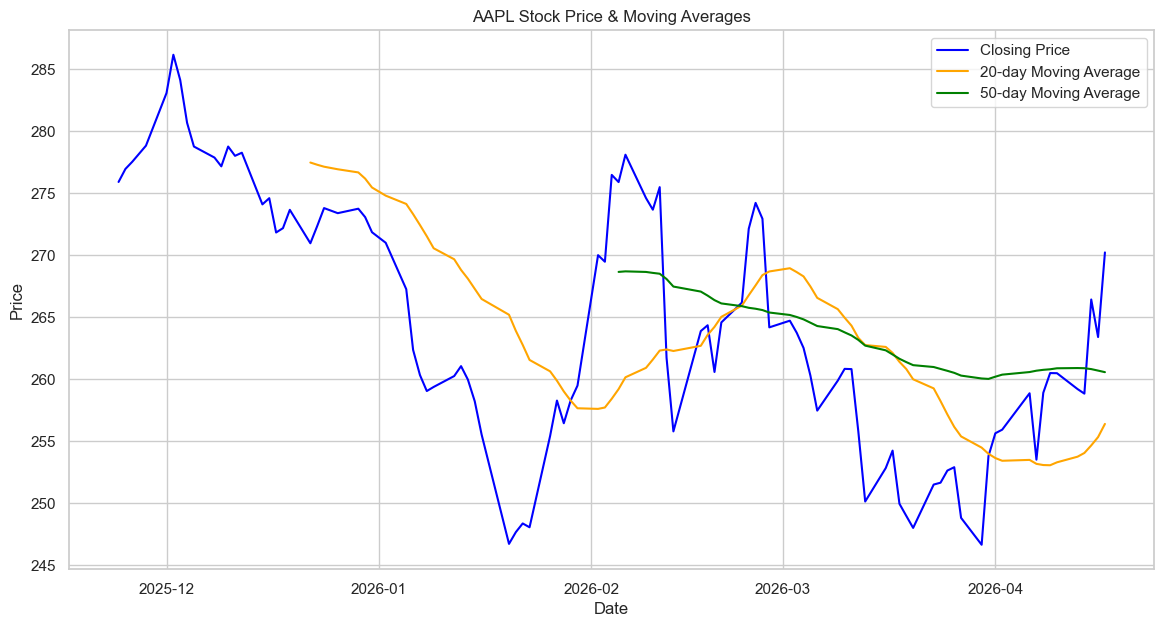

In [5]:
import matplotlib.pyplot as plt

# Plot setup
plt.figure(figsize=(14,7))

# ✅ FIXED: Use Close instead of Adj Close
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
plt.plot(df.index, df['MA20'], label='20-day Moving Average', color='orange')

# If you don't have MA100, use MA50 (safe and existing)
plt.plot(df.index, df['MA50'], label='50-day Moving Average', color='green')

# Chart labels
plt.title('AAPL Stock Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

---

## 6. Daily Return Distribution

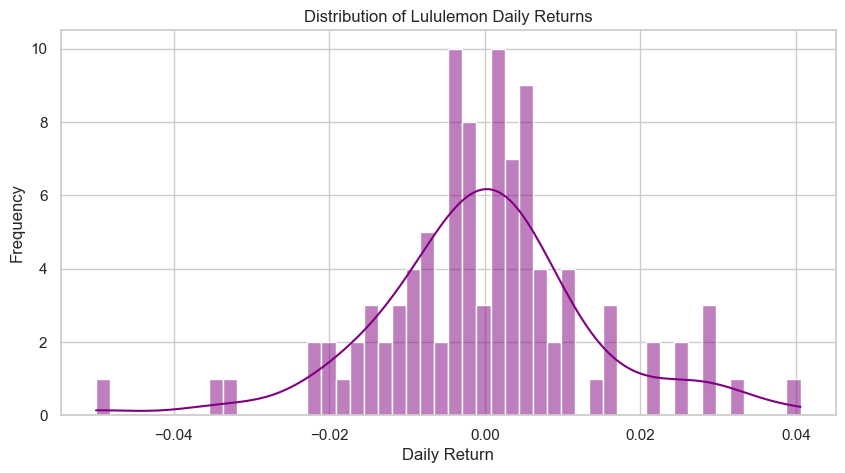

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['Daily Return'], bins=50, kde=True, color='purple')
plt.title('Distribution of Lululemon Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

---

## 7. Daily Returns Time Series

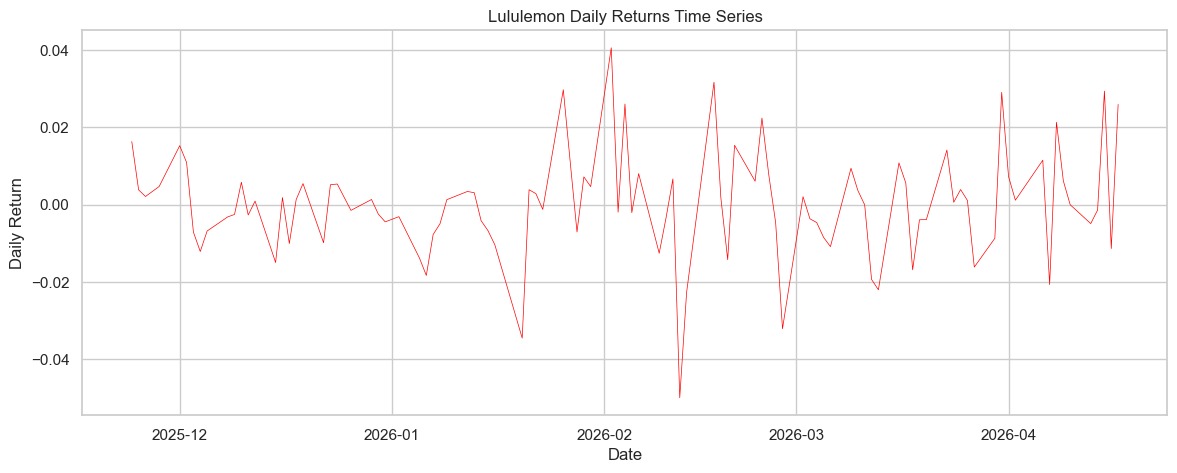

In [7]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Daily Return'], color='red', linewidth=0.5)
plt.title('Lululemon Daily Returns Time Series')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

---

## 8. Historical Volatility Time Series

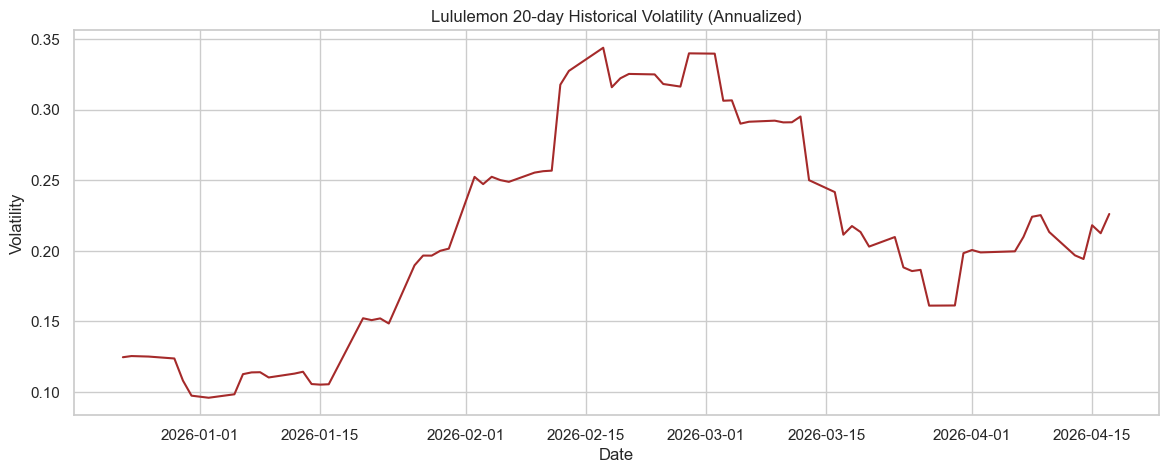

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate 20-day rolling volatility (annualized)
df['Daily Return'] = df['Close'].pct_change()
df['Volatility20'] = df['Daily Return'].rolling(window=20).std() * np.sqrt(252)

# Now plot (NO MORE ERROR)
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Volatility20'], color='brown')
plt.title('Lululemon 20-day Historical Volatility (Annualized)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

---

## 9. Example of Marking Important Events

Mark quarterly earnings release dates to observe price reactions.

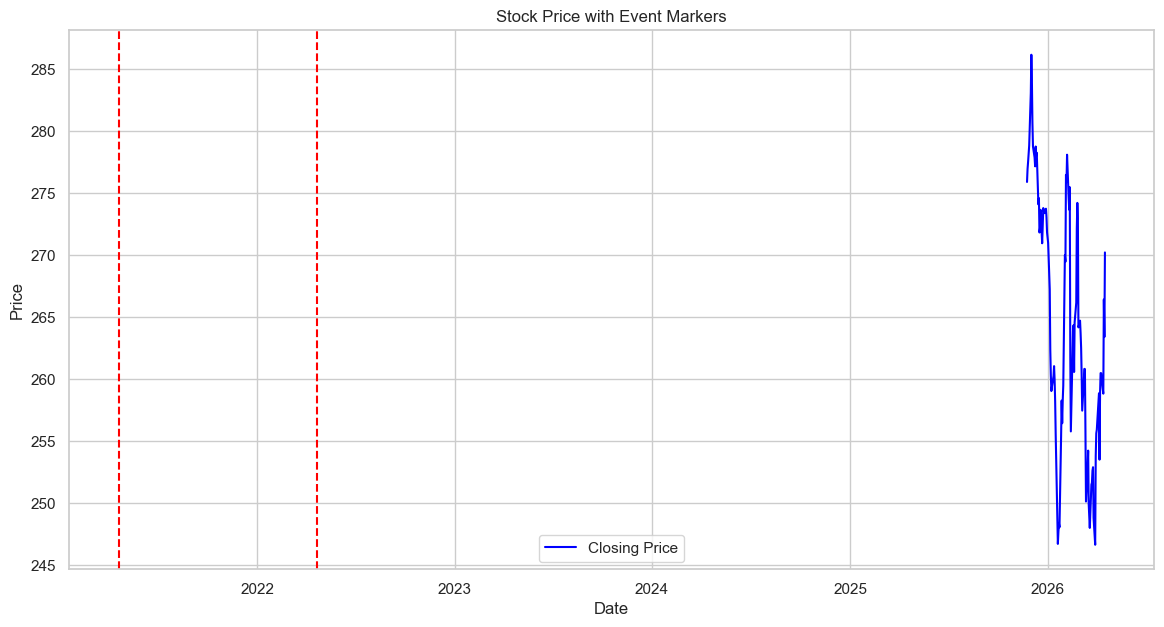

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

event_dates = {
    '2021-04-20': 'Q1 Earnings Release',
    '2022-04-21': 'Q1 Earnings Release'
}

plt.figure(figsize=(14,7))
# ✅ FIXED HERE: Use Close instead of Adj Close
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')

for date, event in event_dates.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--')

plt.title('Stock Price with Event Markers')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

---

## 10. Calculate and Plot Cumulative Returns

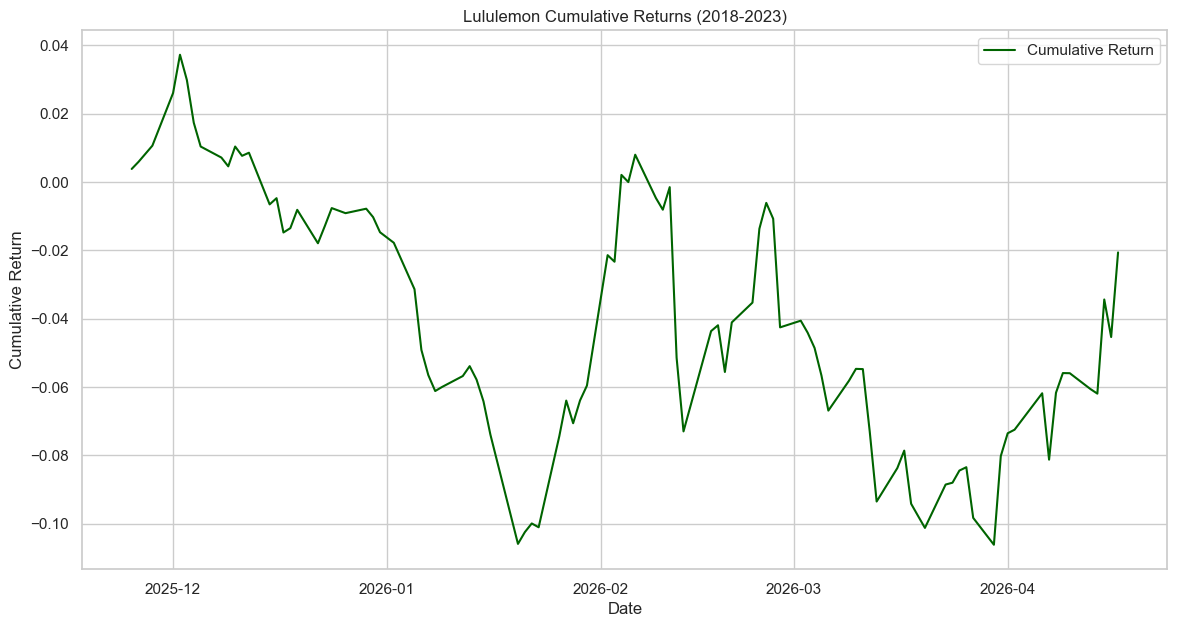

In [10]:
df['Cumulative Return'] = (1 + df['Daily Return']).cumprod() - 1

plt.figure(figsize=(14,7))
plt.plot(df.index, df['Cumulative Return'], label='Cumulative Return', color='darkgreen')
plt.title('Lululemon Cumulative Returns (2018-2023)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

---

## 11. Calculate Key Return Statistics

In [11]:
mean_return = df['Daily Return'].mean()
std_return = df['Daily Return'].std()
annualized_return = mean_return * 252
annualized_volatility = std_return * np.sqrt(252)

print(f"Average Daily Return: {mean_return:.6f}")
print(f"Daily Return Standard Deviation: {std_return:.6f}")
print(f"Estimated Annualized Return: {annualized_return:.2%}")
print(f"Estimated Annualized Volatility: {annualized_volatility:.2%}")

Average Daily Return: -0.000116
Daily Return Standard Deviation: 0.013985
Estimated Annualized Return: -2.92%
Estimated Annualized Volatility: 22.20%


---

## 12. Save Processed Data (Optional)

In [12]:
df.to_csv('Lululemon_Stock_Analysis_Result_AlphaVantage.csv')
print("Processed data saved to Lululemon_Stock_Analysis_Result_AlphaVantage.csv")

Processed data saved to Lululemon_Stock_Analysis_Result_AlphaVantage.csv
